<a href="https://colab.research.google.com/github/TriBot2o/AI_And_ML_Year3/blob/main/Worksheet5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1: Data Understanding and Visualization



## 1. Load and visualize images from a dataset stored in directories, where each subdirec-tory represents a class.

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from PIL import Image

train_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI ML/Data/FruitinAmazon/test"

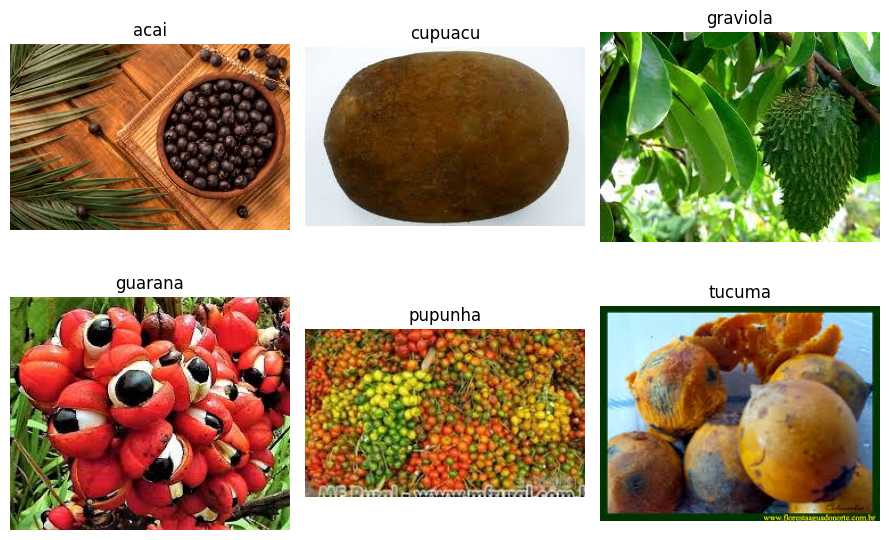

In [ ]:
import random

# Get the list of class directories from the train folder
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])

# Lists to store paths of selected images and their labels
selected_image_paths = []
selected_labels = []

# Select one image randomly from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    # Get all image files in the class directory
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpeg'))]

    if image_files:
        # Select one random image file path
        random_image_file = random.choice(image_files)
        img_path = os.path.join(class_path, random_image_file)
        selected_image_paths.append(img_path)
        selected_labels.append(class_name)

# Display the images in a grid format with two rows using matplotlib
num_images = len(selected_image_paths)
if num_images == 0:
    print("No images found to display.")
else:
    num_rows = 2
    # Calculate number of columns needed to fit all images in 2 rows
    num_cols = (num_images + num_rows - 1) // num_rows

    plt.figure(figsize=(num_cols * 3, num_rows * 3))

    for i, img_path in enumerate(selected_image_paths):
        plt.subplot(num_rows, num_cols, i + 1)
        try:
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(selected_labels[i])
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
            plt.title(f"Error: {selected_labels[i]}")
            plt.axis('off')

    plt.tight_layout()
    plt.show()


## 2. Check for Corrupted Image

In [ ]:
def check_and_remove_corrupted_images(directory):
    corrupted_images_found = False
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.jpeg')):
                image_path = os.path.join(root, file)
                try:
                    with Image.open(image_path) as img:
                        img.verify()  # Verify the image data
                except (IOError, SyntaxError) as e:
                    print(f"Removed corrupted image: {image_path} (Error: {e})")
                    os.remove(image_path)
                    corrupted_images_found = True
                except Exception as e:
                    # Catch other potential errors during loading/verification
                    print(f"Removed problematic image: {image_path} (Unexpected Error: {e})")
                    os.remove(image_path)
                    corrupted_images_found = True

    if not corrupted_images_found:
        print("No Corrupted Images Found.")

print(f"Checking for corrupted images in: {train_dir}")
check_and_remove_corrupted_images(train_dir)


Checking for corrupted images in: /content/drive/MyDrive/AI ML/Data/FruitinAmazon/train
No Corrupted Images Found.


# Task 2: Loading and Preprocessing Inamge Data in keras


In [ ]:
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3 - Implement a CNN with

## Convolutional Architecture

In [ ]:
from tensorflow.keras import layers, models

# Define the CNN model
model = models.Sequential([
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)),
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=(2, 2))
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,144 (39.62 KB)

 Trainable params: 10,144 (39.62 KB)

 Non-trainable params: 0 (0.00 B)

## Fully Connected Network Architecture

In [ ]:
num_classes = len(class_names)

model.add(layers.Flatten())

# Hidden Layer 1
model.add(layers.Dense(64, activation='relu'))

# Hidden Layer 2
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

# Task 4 - Compile the Model

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Task 5 - Train the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

epochs = 250
batch_size_fit = 16

# Define callbacks
checkpoint_filepath = './best_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

early_stopping_callback = EarlyStopping(
    monitor='val_accuracy', # Monitor validation accuracy
    patience=20, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True, # Restore model weights from the epoch with the best value of the monitored quantity
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    batch_size=batch_size_fit,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step - accuracy: 0.1140 - loss: 1.8498
Epoch 1: val_accuracy improved from None to 0.00000, saving model to ./best_model.weights.h5

Epoch 1: finished saving model to ./best_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 606ms/step - accuracy: 0.1389 - loss: 1.8582 - val_accuracy: 0.0000e+00 - val_loss: 1.7072
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.2535 - loss: 1.7685
Epoch 2: val_accuracy improved from 0.00000 to 0.38889, saving model to ./best_model.weights.h5

Epoch 2: finished saving model to ./best_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 463ms/step - accuracy: 0.2917 - loss: 1.7333 - val_accuracy: 0.3889 - val_loss: 1.6796
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.2731 - loss: 1.6195
Epoch 3: val_accuracy improved from 0.38889 to 0.61111, saving model to ./best_model.weights.h5

Epoch 3: finished saving model to ./best_model.weights.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 480ms/step - accuracy

# Task 6 - Evaluate the Model

In [ ]:
# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # No need to shuffle test data
)

# Apply the normalization (Rescaling) to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model on the test dataset
print("\nEvaluating model on the test set...")
loss, accuracy = model.evaluate(test_ds)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 30 files belonging to 6 classes.

Evaluating model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.5667 - loss: 1.0542
Test Loss: 1.0542
Test Accuracy: 0.5667


# Task 7 - Save and Load the Model

In [ ]:
# Define the path to save the model
model_save_path = '/content/drive/MyDrive/AI ML/workshop5.h5'

# Save the entire model to an .h5 file
print(f"Saving the model to: {model_save_path}")
model.save(model_save_path)
print("Model saved successfully!")

# Load the saved model
print(f"\nLoading the model from: {model_save_path}")
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully!")

# Re-evaluate the loaded model on the test dataset
print("\nEvaluating the loaded model on the test set...")
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)

print(f"Loaded Model - Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_accuracy:.4f}")

Saving the model to: /content/drive/MyDrive/AI ML/workshop5.h5


Model saved successfully!

Loading the model from: /content/drive/MyDrive/AI ML/workshop5.h5
Model loaded successfully!

Evaluating the loaded model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 638ms/step - accuracy: 0.5667 - loss: 1.0542
Loaded Model - Test Loss: 1.0542
Loaded Model - Test Accuracy: 0.5667


### Visualizating the training and validation loss and accuracy.

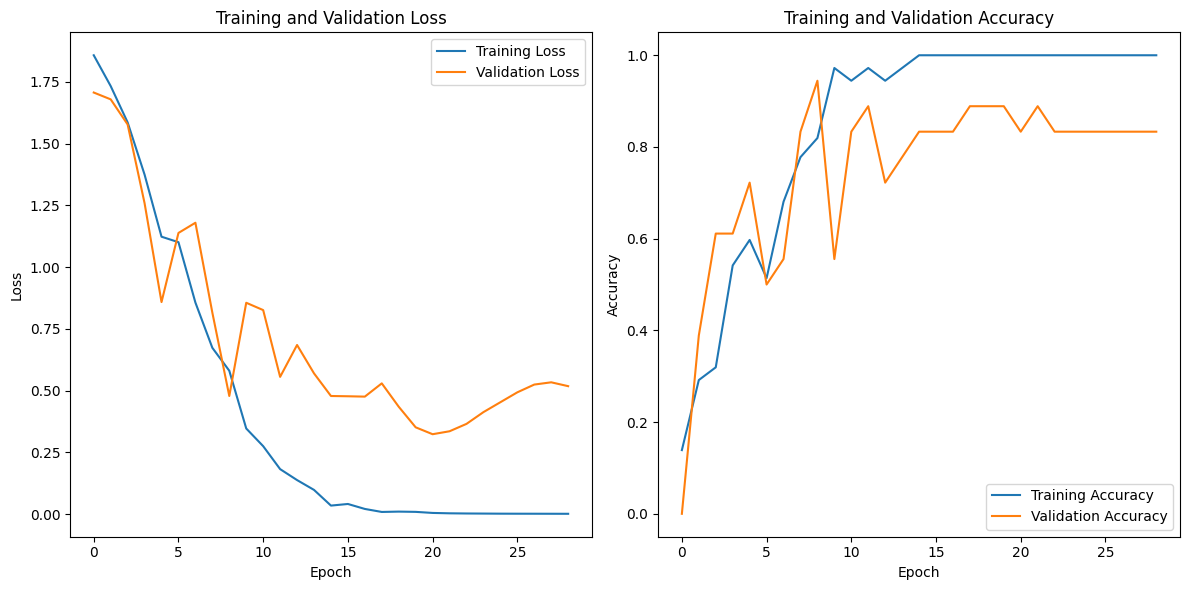

In [ ]:
import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot training and validation accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Task 8 - Predictions and Classification Report

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Make predictions on the test dataset
print("\nMaking predictions on the test set...")
y_pred_probabilities = model.predict(test_ds)

# Convert predicted probabilities to digit labels
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Get class names for the classification report
class_names_for_report = class_names

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names_for_report))


Making predictions on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.44      0.80      0.57         5
     cupuacu       0.50      0.60      0.55         5
    graviola       0.75      0.60      0.67         5
     guarana       1.00      0.20      0.33         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.40      0.40      0.40         5

    accuracy                           0.57        30
   macro avg       0.65      0.57      0.55        30
weighted avg       0.65      0.57      0.55        30

